In [12]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import VerticalPitch,Pitch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import numpy as np

In [ ]:
#SOCCERMATICS_PROJECT 2 

In [1089]:
import requests_cache
requests_cache.uninstall_cache()

In [13]:
sb.competitions()[sb.competitions().country_name=='England']

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
25,37,90,England,FA Women's Super League,female,False,False,2020/2021,2025-04-23T14:16:46.924831,2021-06-13T16:17:31.694,None,2025-04-23T14:16:46.924831
26,37,42,England,FA Women's Super League,female,False,False,2019/2020,2024-02-12T15:05:34.211400,2021-06-13T16:17:31.694,None,2024-02-12T15:05:34.211400
27,37,4,England,FA Women's Super League,female,False,False,2018/2019,2024-08-07T17:22:40.334287,2021-06-13T16:17:31.694,None,2024-08-07T17:22:40.334287
64,2,27,England,Premier League,male,False,False,2015/2016,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
65,2,44,England,Premier League,male,False,False,2003/2004,2025-06-24T13:53:07.585114,2021-06-13T16:17:31.694,None,2025-06-24T13:53:07.585114


In [14]:
match_ids = sb.matches(competition_id = 2, season_id = 27).match_id.values.tolist()

In [16]:
from tqdm import tqdm
events = []
for match_id in tqdm(match_ids):
    data = sb.events(match_id)
    events.append(data)
df = pd.concat(events)

100%|█████████████████████████████████████████| 380/380 [01:37<00:00,  3.89it/s]


In [17]:
df['timestamp']=pd.to_timedelta(df['timestamp'])

In [18]:
df['timestamp_offset'] = pd.Timedelta(0, 'minutes')
df['timestamp_offset'] = df['timestamp_offset'].mask(df['period'] ==2, pd.Timedelta(45, 'minutes'))
df['game_timestamp'] = df['timestamp_offset'] + df['timestamp']

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1443562035.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['timestamp_offset'] = pd.Timedelta(0, 'minutes')
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1443562035.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['game_timestamp'] = df['timestamp_offset'] + df['timestamp']


In [19]:
df_copy = df.sort_values(['match_id','game_timestamp','period','index']).drop(columns = {'timestamp_offset'})

In [20]:
df_copy

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
1521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00.178000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,NaN,NaN,"[75.6, 31.4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:55.036000
892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:56.196000
2925,NaN,NaN,NaN,NaN,Head,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:57.675000
3141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:34:01.683000


In [1172]:
#prob pass results in a shot within 15 seconds

In [21]:
df_copy.reset_index(inplace=True)
df_copy.drop(columns = {'level_0'})

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/2514637977.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy.reset_index(inplace=True)


,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,...,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00.178000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313778,NaN,NaN,"[75.6, 31.4]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:55.036000
1313779,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:56.196000
1313780,NaN,NaN,NaN,NaN,Head,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:33:57.675000
1313781,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:34:01.683000


In [22]:
Passes_copy = df_copy[df_copy['type'] == 'Pass']
Shots_copy = df_copy[df_copy['type'] == 'Shot']

In [23]:
Shots_copy

,level_0,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,...,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
143,3440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:11.382000
366,3441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:08:38.577000
415,3442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:09:47.445000
435,3443,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:11:05.741000
440,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:11:37.263000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313407,3090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:21:16.359000
1313411,3091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:21:17.522000
1313463,3092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:23:22.017000
1313548,3093,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 01:25:01.657000


In [1232]:
practice_df = df_copy[df_copy['match_id'] == 3753972]
practice_df.drop(columns = {'level_0'}, inplace= True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_29764/1578635779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  practice_df.drop(columns = {'level_0'}, inplace= True)


In [1234]:
practice_df.head()

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6bbafb9c-9e4f-45bf-80f2-6f93c8b4d5e2,1,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Swansea City,26,0 days 00:00:00,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,07aa1c9f-aff7-42aa-b763-39a478b8e5ea,2,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 4411, 'lineup': [{'player': {'id...",AFC Bournemouth,28,0 days 00:00:00,Starting XI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a893074f-957f-4272-8d64-92020f98337f,3,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Swansea City,26,[0ee3b84e-9975-48e0-819a-daeee9dc8880],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:00:00,Half Start,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:00:00
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0ee3b84e-9975-48e0-819a-daeee9dc8880,4,NaN,NaN,3753972,0,NaN,NaN,NaN,NaN,

In [1269]:
Pass_practice_df = practice_df[practice_df['type'] == 'Pass']
df_copy['play_pattern'].value_counts()

play_pattern
Regular Play      585961
From Throw In     330739
From Free Kick    164457
From Goal Kick     95057
From Corner        53285
From Kick Off      40912
From Keeper        28619
From Counter       12617
Other               2136
Name: count, dtype: int64

In [1254]:
Shot_practice_df = practice_df[practice_df['type'] == 'Shot']
Shot_practice_df

,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp
143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.287115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,c0218ff0-32e8-46de-8ed4-a22e7ee4fd48,143,NaN,"[101.8, 49.1]",3753972,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,8,AFC Bournemouth,28,"[03020beb-adb6-401a-8beb-c21a4c493f5c, 5c874ed...",11,NaN,Left Foot,"[120.0, 33.2, 3.1]",True,"[{'location': [101.3, 51.7], 'player': {'id': ...",e38f4438-699d-42c3-befb-4762a172c6c3,NaN,Off T,0.115552,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:03:11.382000,Shot,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:03:11.382000
366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.048003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d87ec24d-e894-4033-a1c3-85da30039ec6,366,NaN,"[80.9, 43.8]",3753972,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Dan Gosling,3343.0,Left Defensive Midfield,24,AFC Bournemouth,28,"[1e76b183-74be-44d8-9c63-53de7c9481ba, 7355d1d...",38,NaN,Right Foot,"[81.7, 43.7]",NaN,"[{'location': [117.4, 40.4], 'player': {'id': ...",6cebddd1-0ec1-4a2c-a0d3-a58d87fe0fbb,NaN,Blocked,0.006542,Half Volley,Open Play,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:08:38.577000,Shot,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:08:38.577000
415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.745855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71a9e4f9-5755-4040-8756-18b4b76f77a0,415,NaN,"[111.9, 39.9]",3753972,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Joshua King,3346.0,Center Forward,26,AFC Bournemouth,28,[369513fa-8903-4d3b-96a4-39eca3e4edb5],47,NaN,Right Foot,

In [ ]:
#Passes 15 seconds before shot

#Pass_practice_df['period'] == #Same period as shot
#Pass_practice_df['game_timestamp'] < shot timestamp
##Shot game_timestamp - Pass_practice_df['game_timestamp'] < pd.Timedelta(15, 'seconds')


    

In [1279]:
passes_within_15s_shot = []

for i in range(len(Shots_copy)):
    shot_time = Shots_copy.iloc[i]['game_timestamp']
    shot_period = Shots_copy.iloc[i]['period']
    shot_team = Shots_copy.iloc[i]['team']
    shot_match = Shots_copy.iloc[i]['match_id']

    # All conditions inside one block
    prior_passes = df_copy[
        (df_copy['period'] == shot_period) &
        (df_copy['game_timestamp'] < shot_time) &
        (shot_time - df_copy['game_timestamp'] <= pd.Timedelta(seconds=15)) &
        (df_copy['type'] == 'Pass') &
        (df_copy['team'] == shot_team) &
        (df_copy['match_id'] == shot_match)
    ].copy()

    prior_passes['linked_shot_time'] = shot_time
    passes_within_15s_shot.append(prior_passes)

passes_within_15s_shot_df = pd.concat(passes_within_15s_shot)


In [27]:
passes_within_15s_shot = []
for i in tqdm(range(len(Shots_copy))):
    shot_time = Shots_copy.iloc[i]['game_timestamp']
    shot_period = Shots_copy.iloc[i]['period']
    shot_team = Shots_copy.iloc[i]['team']
    shot_match = Shots_copy.iloc[i]['match_id']
    shot_index = Shots_copy.index[i]
    shot_id = Shots_copy.iloc[i].get('id')
    prior_passes = Passes_copy[(Passes_copy['game_timestamp']<shot_time)&
                          (shot_time - Passes_copy['game_timestamp']<= pd.Timedelta(seconds=15))&
                          (Passes_copy['period'] == shot_period)&
                          (Passes_copy['team'] == shot_team)&
                          (Passes_copy['match_id'] == shot_match)&
                          (Passes_copy['pass_outcome'].isna())].copy()  # Add this line
    prior_passes['linked_shot_time'] = shot_time
    prior_passes['linked_shot_index'] = shot_index
    prior_passes['linked_shot_id'] = shot_id
    passes_within_15s_shot.append(prior_passes)
passes_within_15s_shot_df = pd.concat(passes_within_15s_shot)

100%|███████████████████████████████████████| 9908/9908 [19:04<00:00,  8.66it/s]


In [28]:
passes_within_15s_shot_df.shape

(25259, 123)

In [29]:
passes_df = df_copy[df_copy['type'] == 'Pass']
passes_df.shape

(368619, 120)

In [30]:
passes_df['within_15s_shot'] = 0
passes_df['within_15s_shot']=passes_df['within_15s_shot'].mask(passes_df.index.isin(passes_within_15s_shot_df.index.unique()),1)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3221333234.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes_df['within_15s_shot'] = 0
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3221333234.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df['within_15s_shot'] = 0
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3221333234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [31]:
passes_df.drop(columns = {'level_0'}, inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1462130448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df.drop(columns = {'level_0'}, inplace=True)


In [32]:
passes_df[['x','y']] = passes_df['location'].apply(pd.Series)
passes_df[['end_x','end_y']] = passes_df['pass_end_location'].apply(pd.Series)
passes_df.drop(columns = {'location','pass_end_location'}, inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1020591157.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  passes_df[['x','y']] = passes_df['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1020591157.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df[['x','y']] = passes_df['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1020591157.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is 

In [33]:
passes_df[['x','y','end_x','end_y','within_15s_shot']].within_15s_shot.value_counts()

within_15s_shot
0    344769
1     23850
Name: count, dtype: int64

In [37]:
#passes_df_copy = passes_df[['x','y','end_x','end_y','within_15s_shot']]


In [42]:
# Goal coordinate (right side attack)
GOAL_X, GOAL_Y = 120, 40

# Distance from end of pass to goal (Euclidean)
passes_df_copy['dist_to_goal'] = np.sqrt(
    (GOAL_X - passes_df_copy['end_x'])**2 + 
    (GOAL_Y - passes_df_copy['end_y'])**2
)

# Squared distance (non-linear effect)
passes_df_copy['dist_to_goal_sq'] = passes_df_copy['dist_to_goal']**2




/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3133110198.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df_copy['dist_to_goal'] = np.sqrt(
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3133110198.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df_copy['dist_to_goal_sq'] = passes_df_copy['dist_to_goal']**2


In [43]:
passes_df_copy[['x','y','end_x','end_y','dist_to_goal','dist_to_goal_sq','within_15s_shot']]

,x,y,end_x,end_y,dist_to_goal,dist_to_goal_sq,within_15s_shot
5,61.0,40.1,60.2,40.7,59.804097,3576.53,0
7,60.5,42.1,52.4,41.6,67.618932,4572.32,0
11,53.1,42.3,33.2,60.9,89.280737,7971.05,0
14,33.4,59.7,28.5,31.1,91.931823,8451.46,0
17,28.5,33.9,26.8,60.2,95.363934,9094.28,0
...,...,...,...,...,...,...,...
1313767,81.6,80.0,84.6,63.0,42.215637,1782.16,0
1313770,83.9,62.2,72.6,47.2,47.943717,2298.60,0
1313773,77.1,33.1,80.3,17.9,45.436769,2064.50,0
1313776,82.8,14.5,77.3,27.5,44.492022,1979.54,0


In [44]:
#Remember task: based on my features (where the pass location (started and ended)) how can we predict if the pass will be followed by a shot or not)
#logistic regression classifier

X = passes_df_copy[['x', 'y', 'end_x', 'end_y','dist_to_goal','dist_to_goal_sq']]
y = passes_df_copy['within_15s_shot']

X,y

(            x     y  end_x  end_y  dist_to_goal  dist_to_goal_sq
 5        61.0  40.1   60.2   40.7     59.804097          3576.53
 7        60.5  42.1   52.4   41.6     67.618932          4572.32
 11       53.1  42.3   33.2   60.9     89.280737          7971.05
 14       33.4  59.7   28.5   31.1     91.931823          8451.46
 17       28.5  33.9   26.8   60.2     95.363934          9094.28
 ...       ...   ...    ...    ...           ...              ...
 1313767  81.6  80.0   84.6   63.0     42.215637          1782.16
 1313770  83.9  62.2   72.6   47.2     47.943717          2298.60
 1313773  77.1  33.1   80.3   17.9     45.436769          2064.50
 1313776  82.8  14.5   77.3   27.5     44.492022          1979.54
 1313779  75.6  31.4  104.2   37.4     16.012495           256.40
 
 [368619 rows x 6 columns],
 5          0
 7          0
 11         0
 14         0
 17         0
           ..
 1313767    0
 1313770    0
 1313773    0
 1313776    0
 1313779    0
 Name: within_15s_shot, 

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#essentially split data randomly where 80% of it will be for training and 20% will be for testing

In [51]:
# 3. Fit model
model_part2 = LogisticRegression()
model_part2.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [209]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, confusion_matrix,classification_report
# 4. Evaluate
y_pred = model_part2.predict(X_test)
#print("Accuracy:", accuracy_score(y_test, y_pred))
roc_auc_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)


array([[68923,     0],
       [ 4801,     0]])

In [211]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     68923
           1       0.00      0.00      0.00      4801

    accuracy                           0.93     73724
   macro avg       0.47      0.50      0.48     73724
weighted avg       0.87      0.93      0.90     73724



In [212]:
roc_auc_score(y_test,y_pred)

0.5

In [54]:
model_part2.coef_

array([[ 0.0204627 ,  0.00029198, -0.02849419, -0.00146055, -0.01688412,
        -0.0003619 ]])

In [ ]:
#We have the passes_within_15s_shot_df
#From this we are going to see/find which passes were ones where it led to a goal
#STEP 3 

In [1457]:
passes_within_15s_shot_df.head()
passes_within_15s_shot_df[passes_within_15s_shot_df['match_id']==3753972]
passes_within_15s_shot_df[passes_within_15s_shot_df['linked_shot_id'] == '71a9e4f9-5755-4040-8756-18b4b76f77a0']

,level_0,ball_receipt_outcome,ball_recovery_recovery_failure,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_punched_out,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,miscontrol_aerial_won,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_deflected,pass_end_location,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure,50_50,bad_behaviour_card,ball_recovery_offensive,block_offensive,goalkeeper_shot_saved_off_target,shot_open_goal,shot_saved_off_target,goalkeeper_shot_saved_to_post,injury_stoppage_in_chain,pass_goal_assist,pass_straight,pass_no_touch,clearance_other,pass_miscommunication,shot_saved_to_post,block_deflection,dribble_no_touch,shot_redirect,block_save_block,shot_deflected,player_off_permanent,goalkeeper_success_in_play,shot_follows_dribble,goalkeeper_lost_out,half_start_late_video_start,goalkeeper_lost_in_play,goalkeeper_penalty_saved_to_post,goalkeeper_saved_to_post,game_timestamp,linked_shot_time,linked_shot_index,linked_shot_id
404,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.532810,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d2467eef-7952-478d-b79c-b0de68fd0e00,404,NaN,"[49.1, 19.4]",3753972,9,NaN,NaN,NaN,NaN,-0.264207,NaN,Left Foot,NaN,NaN,NaN,"[69.8, 13.8]",High Pass,NaN,21.444113,NaN,NaN,Junior Stanislas,3463.0,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Charlie Daniels,3345.0,Left Back,26,AFC Bournemouth,28,[7c346c7c-8055-4371-9e6c-3cba4c93afca],38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:09:38.292000,Pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:09:38.292000,0 days 00:09:47.445000,415,71a9e4f9-5755-4040-8756-18b4b76f77a0
413,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.284867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d4bb0c4c-3bcf-4a80-bb89-c4912f9a6d92,413,NaN,"[112.3, 22.1]",3753972,9,NaN,NaN,NaN,NaN,1.613551,71a9e4f9-5755-4040-8756-18b4b76f77a0,Left Foot,True,NaN,NaN,"[111.5, 40.8]",Ground Pass,NaN,18.717104,NaN,NaN,Joshua King,3346.0,NaN,NaN,NaN,NaN,Recovery,1,Regular Play,Junior Stanislas,3463.0,Left Midfield,26,AFC Bournemouth,28,"[0ca637c9-ea29-4984-afc7-4272946b519e, b35247b...",46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFC Bournemouth,28,0 days 00:09:46.137000,Pass,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:09:46.137000,0 days 00:09:47.445000,415,71a9e4f9-5755-4040-8756-18b4b76f77a0


In [55]:
passes_within_15s_shot_df.shape

(25259, 123)

In [1391]:
#passes_within_15s_shot_df.index

Index([    126,     128,     132,     136,     140,     352,     362,     404,
           413,     422,
       ...
       1313265, 1313294, 1313404, 1313404, 1313451, 1313455, 1313460, 1313543,
       1313545, 1313679],
      dtype='int64', length=28219)

In [1453]:
Shots_copy[Shots_copy['shot_outcome'] == 'Goal']['id'].iloc[0]

'71a9e4f9-5755-4040-8756-18b4b76f77a0'

In [57]:
Goal_id = Shots_copy[Shots_copy['shot_outcome'] == 'Goal']['id']
Goal_id

415        71a9e4f9-5755-4040-8756-18b4b76f77a0
1061       ea41074c-9b8f-4276-9228-c4f6930af5ca
1101       d0069522-abf4-4466-9aa3-a352103cef44
1397       8f2cb467-bd16-435b-b344-89447a21bff3
4394       f58ea4a3-e524-4bfc-8c55-d38765dfe82e
                           ...                 
1303962    ad393f88-c83e-4c6a-85e6-5f6147bc4390
1307658    66b92fca-5258-4e04-95c5-1489ea3c5a11
1311411    e1e1421e-aad8-4c9c-8db4-1172030bc3dc
1312086    83b14b7b-3f95-48ad-a3db-70f79048f6f2
1313411    a7f4145e-6013-451d-991c-55ebd13e11c4
Name: id, Length: 988, dtype: object

In [58]:
passes_within_15s_shot_df['goal']=0
passes_within_15s_shot_df['goal']=passes_within_15s_shot_df['goal'].mask(passes_within_15s_shot_df['linked_shot_id'].isin(Goal_id),1)
#passes_within_15s_shot_df[passes_within_15s_shot_df['linked_shot_id'].isin(Goal_id)],

In [59]:
passes_within_15s_shot_df_copy = passes_within_15s_shot_df[['location','pass_end_location','goal']]

In [60]:
passes_within_15s_shot_df_copy[['x','y']] = passes_within_15s_shot_df_copy['location'].apply(pd.Series)
passes_within_15s_shot_df_copy[['end_x','end_y']] = passes_within_15s_shot_df_copy['pass_end_location'].apply(pd.Series)
passes_within_15s_shot_df_copy.drop(columns = {'location','pass_end_location'}, inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1471487917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_within_15s_shot_df_copy[['x','y']] = passes_within_15s_shot_df_copy['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/1471487917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_within_15s_shot_df_copy[['x','y']] = passes_within_15s_shot_df_copy['location'].apply(pd.Series)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T

In [61]:
passes_within_15s_shot_df_copy

,goal,x,y,end_x,end_y
126,0,56.0,67.4,54.7,58.5
128,0,54.7,58.5,62.9,63.0
132,0,62.9,63.0,76.7,54.8
136,0,86.1,28.7,94.3,39.1
140,0,99.5,38.6,100.7,50.7
...,...,...,...,...,...
1313404,1,120.0,80.0,113.4,38.2
1313451,0,46.3,13.2,54.4,4.0
1313460,0,64.2,20.0,71.5,11.3
1313543,0,55.9,62.2,78.3,49.8


In [62]:
#copy steps for model (but use linear due to project requirements)


from sklearn.linear_model import LinearRegression
X = passes_within_15s_shot_df_copy[['x', 'y', 'end_x', 'end_y']]
y = passes_within_15s_shot_df_copy['goal']  # 1 if shot was goal, 0 otherwise

model_part3=LinearRegression()
model_part3.fit(X,y)

model_part3.coef_

array([-6.41433164e-04, -1.24534135e-05,  8.69780765e-04,  1.29476117e-04])

In [72]:
#Apply to all passes
X_part2 = passes_df_copy[['x', 'y', 'end_x', 'end_y','dist_to_goal','dist_to_goal_sq']]
passes_df_copy['shot_prob'] = model_part2.predict_proba(X_part2)[:,1]  # model from Part 2

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3320183361.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_df_copy['shot_prob'] = model_part2.predict_proba(X_part2)[:,1]  # model from Part 2


In [80]:
passes_df = pd.merge(passes_df_copy,passes_df)

In [81]:
X_part3 = passes_df[['x', 'y', 'end_x', 'end_y']]
passes_df['goal_given_shot'] = model_part3.predict(X_part3)  # model from Part 3
#clipping values between 0 and 1 as used linear regression here
passes_df['goal_given_shot'] = passes_df['goal_given_shot'].clip(0, 1)

In [82]:
passes_df['xD'] = passes_df['shot_prob'] * passes_df['goal_given_shot']

In [84]:
passes_df[['player','type','pass_recipient','game_timestamp','match_id','xD','pass_outcome','x','y','end_x','end_y','dist_to_goal','dist_to_goal_sq','team']]

,player,type,pass_recipient,game_timestamp,match_id,xD,pass_outcome,x,y,end_x,end_y,dist_to_goal,dist_to_goal_sq,team
0,Éderzito António Macedo Lopes,Pass,Jonjo Shelvey,0 days 00:00:00.548000,3753972,0.005158,NaN,61.0,40.1,60.2,40.7,59.804097,3576.53,Swansea City
1,Jonjo Shelvey,Pass,Leon Britton,0 days 00:00:00.898000,3753972,0.003674,NaN,60.5,42.1,52.4,41.6,67.618932,4572.32,Swansea City
2,Leon Britton,Pass,Kyle Bartley,0 days 00:00:02.683000,3753972,0.000987,NaN,53.1,42.3,33.2,60.9,89.280737,7971.05,Swansea City
3,Kyle Bartley,Pass,Ashley Williams,0 days 00:00:05.470000,3753972,0.000677,NaN,33.4,59.7,28.5,31.1,91.931823,8451.46,Swansea City
4,Ashley Williams,Pass,Kyle Bartley,0 days 00:00:08.436000,3753972,0.000491,NaN,28.5,33.9,26.8,60.2,95.363934,9094.28,Swansea City
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369288,Nathaniel Edwin Clyne,Pass,Adam David Lallana,0 days 01:33:46.187000,3754351,0.010478,NaN,81.6,80.0,84.6,63.0,42.215637,1782.16,Liverpool
369289,Adam David Lallana,Pass,Lucas Pezzini Leiva,0 days 01:33:47.847000,3754351,0.010121,NaN,83.9,62.2,72.6,47.2,47.943717,2298.60,Liverpool
369290,Lucas Pezzini Leiva,Pass,Alberto Moreno Pérez,0 days 01:33:51.331000,3754351,0.009216,NaN,77.1,33.1,80.3,17.9,45.436769,2064.50,Liverpool
369291,Alberto Moreno Pérez,Pass,Lucas Pezzini Leiva,0 days 01:33:53.976000,3754351,0.010747,NaN,82.8,14.5,77.3,27.5,44.492022,1979.54,Liverpool


In [85]:
#Going to Make any pass that is NOT COMPLETE (nan = complete) an xD of zero
passes_df['pass_outcome'].isna().sum()
passes_df['pass_outcome'].value_counts()

pass_outcome
Incomplete          75212
Out                  7514
Unknown              1966
Pass Offside         1381
Injury Clearance      360
Name: count, dtype: int64

In [86]:
passes_df['xD'] = passes_df['xD'].mask(~passes_df['pass_outcome'].isna(),0)

In [1564]:
passes_df.columns.values

array(['ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'carry_end_location', 'clearance_aerial_won',
       'clearance_body_part', 'clearance_head', 'clearance_left_foot',
       'clearance_right_foot', 'counterpress', 'dribble_nutmeg',
       'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type',
       'duration', 'foul_committed_advantage', 'foul_committed_card',
       'foul_committed_offensive', 'foul_committed_penalty',
       'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive',
       'foul_won_penalty', 'goalkeeper_body_part',
       'goalkeeper_end_location', 'goalkeeper_outcome',
       'goalkeeper_position', 'goalkeeper_punched_out',
       'goalkeeper_technique', 'goalkeeper_type', 'id', 'index',
       'interception_outcome', 'match_id', 'minute',
       'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won',
       'pass_angle', 'pass_assisted_shot_id', 'pass_body_part',
       'pass_cross', 'pass_cut_back', 'pass_deflec

In [87]:
xD_df = pd.DataFrame(passes_df.groupby('player')['xD'].sum().sort_values()).reset_index()

In [88]:
player_df = pd.DataFrame(passes_df[['player','team']].value_counts()).reset_index().drop(columns = {'count'})

In [89]:
xD_df = pd.merge(player_df,xD_df)
xD_df

,player,team,xD
0,Francesc Fàbregas i Soler,Chelsea,16.914515
1,Mesut Özil,Arsenal,19.942729
2,Simon Francis,AFC Bournemouth,8.972395
3,Andrew Surman,AFC Bournemouth,9.901305
4,Ignacio Monreal Eraso,Arsenal,11.403768
...,...,...,...
551,João Carlos Vilaça Teixeira,Liverpool,0.006755
552,Ivan Toney,Newcastle United,0.000847
553,Tyrone Mings,AFC Bournemouth,0.015547
554,Nick Powell,Manchester United,0.006370


In [1698]:
#use minutes played function from previous to get the xD/90

In [90]:
passes_df[['player','type','pass_recipient','game_timestamp','match_id','xD','pass_outcome','x','y','end_x','end_y','team', 'pass_type','pass_shot_assist']].sort_values('xD', ascending=False).head()

,player,type,pass_recipient,game_timestamp,match_id,xD,pass_outcome,x,y,end_x,end_y,team,pass_type,pass_shot_assist
328269,Ryan Bertrand,Pass,José Miguel da Rocha Fonte,0 days 01:08:19.944000,3754309,0.028251,NaN,120.0,80.0,117.2,40.4,Southampton,Corner,NaN
189262,Leighton Baines,Pass,Romelu Lukaku Menama,0 days 00:36:27.098000,3754166,0.028140,NaN,120.0,80.0,115.2,40.2,Everton,Corner,True
309974,David Josué Jiménez Silva,Pass,Fernando Francisco Reges,0 days 00:53:48.182000,3754290,0.028137,NaN,120.0,80.0,116.1,41.2,Manchester City,Corner,True
129519,Ross Barkley,Pass,Guangtai Jiang,0 days 00:43:44.096000,3754105,0.028080,NaN,120.0,80.0,114.7,40.8,Everton,Corner,True
65200,Robert Brady,Pass,Ryan Bennett,0 days 01:29:21.135000,3754038,0.028070,NaN,120.0,80.0,116.1,41.7,Norwich City,Corner,NaN


In [91]:
passes_df[(passes_df['pass_shot_assist'] == True) & (passes_df['pass_type']!='Corner')].sort_values('xD', ascending =False)[['player','type','pass_recipient','game_timestamp','match_id','xD','pass_outcome','x','y','end_x','end_y','team', 'pass_type','pass_shot_assist','pass_length']].head(10)

,player,type,pass_recipient,game_timestamp,match_id,xD,pass_outcome,x,y,end_x,end_y,team,pass_type,pass_shot_assist,pass_length
302315,Cédric Ricardo Alves Soares,Pass,Jay Rodriguez,0 days 00:55:29.090000,3754282,0.027901,NaN,119.4,51.3,115.2,39.3,Southampton,Recovery,True,12.713772
84017,Junior Stanislas,Pass,Joshua King,0 days 00:13:10.184000,3754058,0.027842,NaN,119.6,27.8,114.3,40.2,AFC Bournemouth,NaN,True,13.485177
46871,Anthony Martial,Pass,Ander Herrera Agüera,0 days 00:55:21.650000,3754019,0.027569,NaN,117.9,24.1,116.9,40.6,Manchester United,NaN,True,16.530275
979,Junior Stanislas,Pass,Dan Gosling,0 days 01:27:52.710000,3753972,0.027397,NaN,117.9,32.2,114.0,39.2,AFC Bournemouth,Recovery,True,8.013114
323438,Wilfried Zaha,Pass,Connor Wickham,0 days 00:51:35.130000,3754304,0.027367,NaN,118.8,24.4,116.2,37.1,Crystal Palace,NaN,True,12.963410
296519,Fabricio Coloccini,Pass,Chancel Mbemba Mangulu,0 days 01:13:04.911000,3754276,0.027353,NaN,117.7,28.8,116.4,38.2,Newcastle United,NaN,True,9.489468
145689,Nordin Amrabat,Pass,Odion Jude Ighalo,0 days 01:06:37.307000,3754121,0.027352,NaN,119.5,56.4,111.2,42.8,Watford,NaN,True,15.932671
137208,Dušan Tadić,Pass,Sadio Mané,0 days 00:15:05.381000,3754113,0.027344,NaN,117.9,72.3,112.8,38.7,Southampton,NaN,True,33.984848
9661,Jordan Veretout,Pass,Joleon Lescott,0 days 00:57:34.754000,3753981,0.027329,NaN,119.2,0.1,113.7,43.1,Aston Villa,Throw-in,True,43.350320
75398,Jamie Vardy,Pass,Shinji Okazaki,0 days 00:12:39.363000,3754049,0.027317,NaN,117.9,53.8,117.2,42.5,Leicester City,NaN,True,11.321661


In [92]:
import pandas as pd
from tqdm.auto import tqdm
from statsbombpy import sb


def get_minutes_played4(df, match_id, player_id, match_durations):
    """
    Calculates minutes played for a player in a match using pre-calculated match durations.

    Args:
        df (DataFrame): DataFrame of events for the match.
        match_id (int): Match ID.
        player_id (int): Player ID.
        match_durations (DataFrame): DataFrame containing pre-calculated durations for each match and period.

    Returns:
        float: Total minutes played by the player in the match.
    """

    df['timestamp'] = pd.to_timedelta(df['timestamp'])

    player_info_df = df[(df['match_id'] == match_id) & (df['player_id'] == player_id)]
    if player_info_df.empty:
        return 0  # If player not found in the match, assume 0 minutes played

    team = player_info_df['team'].iloc[0]
    player_name = player_info_df['player'].iloc[0]

    try:
        lineup = df[(df['match_id'] == match_id) & (df['team'] == team) & (df['type'] == 'Starting XI')]['tactics'].values[0]
        starting_xi = [x['player']['name'] for x in lineup['lineup']]
        starter = player_name in starting_xi
    except IndexError:
        return 0

    durations = {
        period: match_durations[
            (match_durations['match_id'] == match_id) & (match_durations['period'] == period)
        ]['duration_minutes'].values[0] if not match_durations[
            (match_durations['match_id'] == match_id) & (match_durations['period'] == period)
        ]['duration_minutes'].empty else 0
        for period in range(1, 5)
    }

    min_played = 0

    if starter:
        min_played = sum(durations.values())
    
    else:
        entered = df[
            (df['match_id'] == match_id) &
            (df['team'] == team) &
            (df['type'] == 'Substitution') &
            (df['substitution_replacement'] == player_name)  # Changed from player to player_name
        ][['timestamp', 'period']]
        if not entered.empty:
            entered_period = entered['period'].values[0]
            entered_time = pd.Timedelta(entered['timestamp'].values[0]).total_seconds() / 60
            min_played = sum(durations[p] for p in range(entered_period+1, 5))  # Time in future periods
            min_played += (durations[entered_period] - entered_time) if entered_period in durations else 0  # Time in current period
    


    was_sub = df[
        (df['match_id'] == match_id) &
        (df['team'] == team) &
        (df['player_id'] == player_id) &
        (df['type'] == 'Substitution')
    ][['timestamp', 'period']]
    if not was_sub['timestamp'].empty:
        sub_period = was_sub['period'].values[0]
        sub_time = pd.Timedelta(was_sub['timestamp'].values[0]).total_seconds() / 60
        time_remaining_in_sub_period = durations[sub_period] - sub_time if sub_period in durations else 0
        min_played -= time_remaining_in_sub_period
        min_played -= sum(durations[p] for p in range(sub_period + 1, 5))

    was_excluded = df[
        (df['match_id'] == match_id) &
        (df['team'] == team) &
        (df['player_id'] == player_id) &
        (df.apply(lambda row: (
            row.get('bad_behaviour', {}).get('card', {}).get('name') in ['Red Card', 'Second Yellow'] or
            row.get('foul_committed', {}).get('card', {}).get('name') in ['Red Card', 'Second Yellow']
        ), axis=1))
    ][['timestamp', 'period']]
    if not was_excluded['timestamp'].empty:
        exclusion_period = was_excluded['period'].values[0]
        exclusion_time = was_excluded['timestamp'].values[0].total_seconds() / 60
        time_remaining_in_exclusion_period = durations[exclusion_period] - exclusion_time if exclusion_period in durations else 0
        min_played -= time_remaining_in_exclusion_period
        min_played -= sum(durations[p] for p in range(exclusion_period + 1, 5))

    return min_played

def get_all_minutes_by_match(match_ids, get_minutes_played_func):
    """Calculates total minutes played for all players across multiple matches.

    Args:
        match_ids (list): List of match IDs to process.
        get_minutes_played_func (function): Function to calculate minutes played for a player in a match.

    Returns:
        DataFrame: DataFrame with player IDs, names, total minutes, and teams.
    """

    all_player_minutes = []

    for match_id in tqdm(match_ids):
        events_df = sb.events(match_id)  # Load events for the current match
        match_durations = events_df.groupby(['match_id', 'period'])['timestamp'].max().reset_index()
        match_durations['duration_minutes'] = pd.to_timedelta(match_durations['timestamp']).dt.total_seconds() / 60
        all_players = events_df[['player_id', 'player', 'team']].drop_duplicates().dropna()

        for _, row in all_players.iterrows():
            player_id = row['player_id']
            player_name = row['player']
            team = row['team']

            min_played = get_minutes_played_func(events_df, match_id, player_id, match_durations)
            all_player_minutes.append([match_id, player_id, player_name, min_played, team])

    all_minutes_df = pd.DataFrame(all_player_minutes, columns=['match_id', 'player_id', 'player_name', 'minutes_played', 'team'])

    # Aggregate minutes played for each player across all matches
    final_df = all_minutes_df.groupby(['player_id', 'player_name', 'team'])['minutes_played'].sum().reset_index()
    final_df.rename(columns={'minutes_played': 'total_minutes'}, inplace=True)

    return final_df



/opt/anaconda3/envs/spyder-5.4.3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [93]:
match_ids = sb.matches(competition_id = 2, season_id = 27).match_id.values.tolist()

In [94]:
Minutes_Played = get_all_minutes_by_match(match_ids, get_minutes_played4)

100%|█████████████████████████████████████████| 380/380 [11:58<00:00,  1.89s/it]


In [95]:
Minutes_Played

,player_id,player_name,team,total_minutes
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433
2,2988.0,Memphis Depay,Manchester United,1605.272250
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350
4,3041.0,Ciaran Clark,Aston Villa,1547.219983
...,...,...,...,...
555,75899.0,Kevin Toner,Aston Villa,338.878617
556,128703.0,Dionatan do Nascimento Teixeira,Stoke City,50.723983
557,128704.0,Emmanuel Emenike,West Ham United,566.869483
558,129558.0,Tony Hibbert,Everton,49.608467


In [1724]:
Minutes_Played[~Minutes_Played['player_name'].isin(xD_df['player'])]

,player_id,player_name,team,total_minutes
302,4837.0,Josh Cullen,West Ham United,1.433183
386,9635.0,Will Keane,Manchester United,8.794883
387,9636.0,Rushian Hepburn-Murphy,Aston Villa,6.289200
498,24120.0,Jamie Sterry,Newcastle United,9.351217


In [96]:
xD_final_df = pd.merge(Minutes_Played.rename(columns = {'player_name':'player'}), xD_df)
xD_final_df.head()

,player_id,player,team,total_minutes,xD
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950,0.999648
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433,4.147365
2,2988.0,Memphis Depay,Manchester United,1605.272250,4.910739
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350,7.270007
4,3041.0,Ciaran Clark,Aston Villa,1547.219983,1.352314


In [97]:
position_df = pd.DataFrame(passes_df.groupby(['player','player_id'])['position'].value_counts()).reset_index().groupby(['player','player_id']).head(1)

In [98]:
position_df.head()


,player,player_id,position,count
0,Aaron Cresswell,3062.0,Left Back,1765
2,Aaron Lennon,3953.0,Right Wing,342
10,Aaron Ramsey,3517.0,Left Defensive Midfield,929
16,Abdul Rahman Baba,12325.0,Left Back,639
20,Adam David Lallana,4090.0,Center Attacking Midfield,340


In [99]:
xD_final_df[xD_final_df.duplicated('player')]

,player_id,player,team,total_minutes,xD
11,3057.0,Jonjo Shelvey,Swansea City,1290.516967,6.742397
21,3085.0,Glenn Murray,Crystal Palace,131.971783,1.040786
57,3297.0,Andros Townsend,Tottenham Hotspur,78.629617,2.944432
189,3631.0,Nathan Dyer,Swansea City,23.326000,0.620426
204,3656.0,Alex Pritchard,West Bromwich Albion,74.586567,0.182544
368,9528.0,Steven Naismith,Norwich City,915.648800,3.100895
378,9593.0,Lewis Grabban,Norwich City,270.000917,2.059348
393,9958.0,Steven Caulker,Southampton,161.059817,0.265820
398,10457.0,Patrick Bamford,Norwich City,263.840800,0.543118
471,20285.0,Joleon Lescott,West Bromwich Albion,192.473483,2.545585


In [100]:
xD_final_df[xD_final_df['player'] == 'Jonjo Shelvey']

,player_id,player,team,total_minutes,xD
10,3057.0,Jonjo Shelvey,Newcastle United,1125.156400,6.742397
11,3057.0,Jonjo Shelvey,Swansea City,1290.516967,6.742397


In [101]:
xD_final_df

,player_id,player,team,total_minutes,xD
0,2956.0,Bertrand Isidore Traoré,Chelsea,409.646950,0.999648
1,2966.0,Stéphane Sessègnon,West Bromwich Albion,1859.842433,4.147365
2,2988.0,Memphis Depay,Manchester United,1605.272250,4.910739
3,3037.0,Mousa Sidi Yaya Dembélé,Tottenham Hotspur,2395.127350,7.270007
4,3041.0,Ciaran Clark,Aston Villa,1547.219983,1.352314
...,...,...,...,...,...
551,75899.0,Kevin Toner,Aston Villa,338.878617,0.432655
552,128703.0,Dionatan do Nascimento Teixeira,Stoke City,50.723983,0.002456
553,128704.0,Emmanuel Emenike,West Ham United,566.869483,1.084260
554,129558.0,Tony Hibbert,Everton,49.608467,0.101463


In [102]:
xD_final_df['player_clean'] = xD_final_df['player'].str.strip()

aggregated_df = xD_final_df.groupby('player_clean').agg({
    'player_id': 'first',                                 # keep first player_id
    'team': lambda x: ', '.join(sorted(set(x))),          # combine unique team names
    'total_minutes': 'sum',                               # sum of minutes
    'xD': 'first'                                          # keep xD (assumed same)
}).reset_index().rename(columns={'player_clean': 'player'})


In [103]:
position_df.head()
position_df.drop(columns = 'count',inplace=True)

In [104]:
aggregated_df.sort_values('xD',ascending=False)
aggregated_df = pd.merge(aggregated_df, position_df)

In [105]:
aggregated_df['xD/90'] = aggregated_df['xD']*90/aggregated_df['total_minutes']

In [106]:
aggregated_df.sort_values('xD/90',ascending=False).head(25)

,player,player_id,team,total_minutes,xD,position,xD/90
333,Manuel García Alonso,8344.0,Manchester City,14.030300,0.141526,Right Defensive Midfield,0.907847
59,Bersant Celina,9566.0,Manchester City,17.834867,0.126023,Right Midfield,0.635952
367,Mesut Özil,3496.0,Arsenal,3201.010933,19.942729,Center Attacking Midfield,0.560712
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,8.327276,Left Defensive Midfield,0.542579
451,Samir Nasri,20253.0,Manchester City,583.395167,3.434907,Left Wing,0.529901
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,10.670068,Center Attacking Midfield,0.509601
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,16.914515,Right Defensive Midfield,0.488952
378,Mohamed Naser Elsayed Elneny,3568.0,Arsenal,837.883983,4.392181,Right Defensive Midfield,0.471779
225,James Wilson,6361.0,Manchester United,10.377450,0.054302,Right Wing,0.470946
75,Cameron Brannagan,4243.0,Liverpool,123.871433,0.644659,Right Center Midfield,0.468384


In [107]:
aggregated_df[aggregated_df['total_minutes']>=660].sort_values('xD/90',ascending=False).head(25)

,player,player_id,team,total_minutes,xD,position,xD/90
367,Mesut Özil,3496.0,Arsenal,3201.010933,19.942729,Center Attacking Midfield,0.560712
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,8.327276,Left Defensive Midfield,0.542579
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,10.670068,Center Attacking Midfield,0.509601
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,16.914515,Right Defensive Midfield,0.488952
378,Mohamed Naser Elsayed Elneny,3568.0,Arsenal,837.883983,4.392181,Right Defensive Midfield,0.471779
139,Eden Hazard,3621.0,Chelsea,2368.917800,12.238723,Left Wing,0.464974
327,Luis Antonio Valencia Mosquera,3267.0,Manchester United,920.518300,4.231388,Right Back,0.413707
2,Aaron Ramsey,3517.0,Arsenal,2795.386583,12.577516,Left Defensive Midfield,0.404945
296,Kevin De Bruyne,3089.0,Manchester City,2132.360717,9.344881,Center Attacking Midfield,0.394417
27,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,2573.944833,11.219917,Left Wing,0.392313


In [143]:
aggregated_df[aggregated_df['total_minutes']>=950].sort_values('xD/90',ascending=False).head(20)

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
367,Mesut Özil,3496.0,Arsenal,3201.010933,19.942729,Center Attacking Midfield,0.560712,9.475132
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,8.327276,Left Defensive Midfield,0.542579,9.903845
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,10.670068,Center Attacking Midfield,0.509601,8.119172
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,16.914515,Right Defensive Midfield,0.488952,6.417408
139,Eden Hazard,3621.0,Chelsea,2368.917800,12.238723,Left Wing,0.464974,6.192701
2,Aaron Ramsey,3517.0,Arsenal,2795.386583,12.577516,Left Defensive Midfield,0.404945,6.374789
296,Kevin De Bruyne,3089.0,Manchester City,2132.360717,9.344881,Center Attacking Midfield,0.394417,7.597214
27,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,2573.944833,11.219917,Left Wing,0.392313,6.363773
185,Gnégnéri Yaya Touré,3087.0,Manchester City,2466.333383,10.590329,Right Defensive Midfield,0.386456,5.875118
238,Jesús Navas González,6821.0,Manchester City,2439.039917,10.386909,Right Wing,0.383274,5.276666


In [112]:
danger_passes_df = pd.DataFrame(passes_df.groupby(['player','player_id'])['within_15s_shot'].sum()).reset_index()
danger_passes_df

,player,player_id,within_15s_shot
0,Aaron Cresswell,3062.0,126
1,Aaron Lennon,3953.0,50
2,Aaron Ramsey,3517.0,198
3,Abdul Rahman Baba,12325.0,33
4,Adam David Lallana,4090.0,137
...,...,...,...
540,Youssouf Chafiq Mulumbu Ngangu,16932.0,9
541,Àngel Rangel Zaragoza,3973.0,77
542,Ádám Bogdán,9985.0,0
543,Éderzito António Macedo Lopes,15996.0,10


In [113]:
aggregated_df = pd.merge(aggregated_df,danger_passes_df)
aggregated_df['Danger_Passes/90']=aggregated_df['within_15s_shot']*90/aggregated_df['total_minutes']

In [114]:
aggregated_df.drop(columns = 'within_15s_shot',inplace=True)

In [115]:
aggregated_df

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
0,Aaron Cresswell,3062.0,West Ham United,3575.566867,8.019890,Left Back,0.201867,3.171525
1,Aaron Lennon,3953.0,Everton,1653.360500,3.309924,Right Wing,0.180174,2.721729
2,Aaron Ramsey,3517.0,Arsenal,2795.386583,12.577516,Left Defensive Midfield,0.404945,6.374789
3,Abdul Rahman Baba,12325.0,Chelsea,1098.907217,2.606070,Left Back,0.213436,2.702685
4,Adam David Lallana,4090.0,Liverpool,2240.396800,6.401343,Center Attacking Midfield,0.257151,5.503489
...,...,...,...,...,...,...,...,...
540,Youssouf Chafiq Mulumbu Ngangu,16932.0,Norwich City,389.666450,0.650550,Left Defensive Midfield,0.150255,2.078701
541,Àngel Rangel Zaragoza,3973.0,Swansea City,1942.596650,6.654309,Right Back,0.308292,3.567390
542,Ádám Bogdán,9985.0,Liverpool,190.798400,0.027531,Goalkeeper,0.012986,0.000000
543,Éderzito António Macedo Lopes,15996.0,Swansea City,326.767983,0.418143,Center Forward,0.115167,2.754248


In [148]:
aggregated_df[aggregated_df['total_minutes']>=950].sort_values('xD/90',ascending=False).groupby('position')[['xD/90','Danger_Passes/90']].median().sort_values('xD/90',ascending=False)

,xD/90,Danger_Passes/90
position,,
Center Attacking Midfield,0.263641,5.156698
Right Midfield,0.241248,4.024104
Left Center Midfield,0.238879,3.593651
Left Wing,0.232225,3.448575
Right Center Midfield,0.229455,3.138888
Right Wing,0.225546,3.903630
Left Defensive Midfield,0.223597,3.068950
Right Defensive Midfield,0.212440,2.753164
Right Back,0.212250,2.423569


In [149]:
filtered_df[filtered_df['total_minutes']>=950].sort_values('xD/90',ascending=False).groupby('main_position')[['xD/90','Danger_Passes/90']].median().sort_values('xD/90',ascending=False)

,xD/90,Danger_Passes/90
main_position,,
Attacking Midfield/Winger,0.237041,4.055084
Midfielder,0.221425,3.052412
Full Back,0.210353,2.622011
Center Forward,0.141389,2.270621
Center Back,0.084414,1.095267
Goalkeeper,0.026531,0.322281


In [117]:
aggregated_df

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
0,Aaron Cresswell,3062.0,West Ham United,3575.566867,8.019890,Left Back,0.201867,3.171525
1,Aaron Lennon,3953.0,Everton,1653.360500,3.309924,Right Wing,0.180174,2.721729
2,Aaron Ramsey,3517.0,Arsenal,2795.386583,12.577516,Left Defensive Midfield,0.404945,6.374789
3,Abdul Rahman Baba,12325.0,Chelsea,1098.907217,2.606070,Left Back,0.213436,2.702685
4,Adam David Lallana,4090.0,Liverpool,2240.396800,6.401343,Center Attacking Midfield,0.257151,5.503489
...,...,...,...,...,...,...,...,...
540,Youssouf Chafiq Mulumbu Ngangu,16932.0,Norwich City,389.666450,0.650550,Left Defensive Midfield,0.150255,2.078701
541,Àngel Rangel Zaragoza,3973.0,Swansea City,1942.596650,6.654309,Right Back,0.308292,3.567390
542,Ádám Bogdán,9985.0,Liverpool,190.798400,0.027531,Goalkeeper,0.012986,0.000000
543,Éderzito António Macedo Lopes,15996.0,Swansea City,326.767983,0.418143,Center Forward,0.115167,2.754248


In [118]:
filtered_df = aggregated_df[aggregated_df['total_minutes']>=950].sort_values('xD/90',ascending=False)

In [119]:
filtered_df[filtered_df['position'].isin(['Right Center Forward','Left Center Forward','Center Forward'])].head(14)

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
522,Wayne Mark Rooney,3538.0,Manchester United,2548.191950,7.172755,Center Forward,0.253336,3.743831
464,Sergio Leonel Agüero del Castillo,3237.0,Manchester City,2482.926667,6.044148,Center Forward,0.219086,3.081041
130,Diego da Silva Costa,5198.0,Chelsea,2542.252100,5.848420,Center Forward,0.207044,2.761331
187,Graziano Pellè,11062.0,Southampton,2343.394817,5.110487,Center Forward,0.196272,3.341306
438,Romelu Lukaku Menama,3289.0,Everton,3389.135500,7.310319,Center Forward,0.194129,2.947654
110,Daniel Andre Sturridge,3529.0,Liverpool,1043.228400,2.201538,Center Forward,0.189928,3.192014
277,José Leonardo Ulloa,3671.0,Leicester City,1089.399017,2.272933,Right Center Forward,0.187777,2.726274
508,Troy Deeney,3454.0,Watford,3509.007483,7.080023,Right Center Forward,0.181590,3.334276
528,Wilfried Guemiand Bony,3598.0,Manchester City,1318.401417,2.586690,Center Forward,0.176579,2.662315
89,Christian Benteke Liolo,3380.0,Liverpool,1667.284350,3.252729,Center Forward,0.175582,3.184820


In [120]:
filtered_df[filtered_df['position'].isin(['Left Center Midfield','Right Center Midfield','Left Defensive Midfield','Right Defensive Midfield'])]

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,8.327276,Left Defensive Midfield,0.542579,9.903845
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,16.914515,Right Defensive Midfield,0.488952,6.417408
2,Aaron Ramsey,3517.0,Arsenal,2795.386583,12.577516,Left Defensive Midfield,0.404945,6.374789
185,Gnégnéri Yaya Touré,3087.0,Manchester City,2466.333383,10.590329,Right Defensive Midfield,0.386456,5.875118
54,Bastian Schweinsteiger,18414.0,Manchester United,1272.068850,5.379902,Left Defensive Midfield,0.380633,3.820548
...,...,...,...,...,...,...,...,...
211,Jack Rodwell,18751.0,Sunderland,1277.727600,1.957921,Left Center Midfield,0.137911,2.535752
86,Cheikhou Kouyaté,3684.0,West Ham United,3260.851417,4.831922,Right Center Midfield,0.133362,2.097612
512,Valon Behrami,5540.0,Watford,1396.003300,1.954244,Left Center Midfield,0.125990,1.611744
243,Joe Ledley,4817.0,Crystal Palace,1049.833300,1.446342,Left Center Midfield,0.123992,1.371646


In [121]:
filtered_df[filtered_df['position'].isin(['Left Midfield','Right Midfield','Right Wing','Left Wing'])]


,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
139,Eden Hazard,3621.0,Chelsea,2368.917800,12.238723,Left Wing,0.464974,6.192701
27,Alexis Alejandro Sánchez Sánchez,3385.0,Arsenal,2573.944833,11.219917,Left Wing,0.392313,6.363773
238,Jesús Navas González,6821.0,Manchester City,2439.039917,10.386909,Right Wing,0.383274,5.276666
90,Christian Dannemann Eriksen,3043.0,Tottenham Hotspur,3103.516167,13.088184,Left Wing,0.379549,7.887827
530,Willian Borges da Silva,3472.0,Chelsea,2924.897300,12.070892,Right Wing,0.371425,5.692508
288,Juan Manuel Mata García,3294.0,Manchester United,3118.304100,12.676075,Right Wing,0.365855,4.300414
132,Dimitri Payet,3491.0,West Ham United,2759.375683,10.458752,Left Wing,0.341123,7.077688
422,Philippe Coutinho Correia,3501.0,Liverpool,2158.286033,7.816070,Left Wing,0.325928,6.088164
424,Raheem Sterling,3233.0,Manchester City,2036.511683,7.100189,Left Wing,0.313780,4.640288
78,Carles Gil de Pareja Vicent,6800.0,Aston Villa,1518.855783,5.017522,Right Wing,0.297314,3.673818


In [122]:
filtered_df[filtered_df['position'] == 'Center Attacking Midfield']

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90
367,Mesut Özil,3496.0,Arsenal,3201.010933,19.942729,Center Attacking Midfield,0.560712,9.475132
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,10.670068,Center Attacking Midfield,0.509601,8.119172
296,Kevin De Bruyne,3089.0,Manchester City,2132.360717,9.344881,Center Attacking Midfield,0.394417,7.597214
31,Ander Herrera Agüera,3606.0,Manchester United,1623.431150,6.062313,Center Attacking Midfield,0.336083,3.381726
525,Wes Hoolahan,10966.0,Norwich City,2094.363667,7.697560,Center Attacking Midfield,0.330783,5.156698
402,Oscar dos Santos Emboaba Júnior,40122.0,Chelsea,1898.249400,6.889230,Center Attacking Midfield,0.326633,5.167919
439,Ross Barkley,4275.0,Everton,3268.287267,11.858349,Center Attacking Midfield,0.326548,5.755308
479,Steven Davis,3828.0,Southampton,2763.145467,9.694199,Center Attacking Midfield,0.315755,5.309167
436,Roberto Firmino Barbosa de Oliveira,3535.0,Liverpool,2102.051067,6.157639,Center Attacking Midfield,0.263641,5.394731
229,Jason Puncheon,19688.0,Crystal Palace,2763.538483,8.030202,Center Attacking Midfield,0.261519,4.168569


In [123]:
#filtered_df['grouped_position']

filtered_df['main_position'] = np.nan

In [124]:
filtered_df['main_position'].mask(filtered_df['position'] == 'Goalkeeper', 'Goalkeeper',inplace=True)

/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3259236129.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_df['main_position'].mask(filtered_df['position'] == 'Goalkeeper', 'Goalkeeper',inplace=True)
/var/folders/4j/7b46k2ln1593bnqn_pvk1hvh0000gn/T/ipykernel_37670/3259236129.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Goalkeeper' has dtype incompatible with float64, please explicitly cast to a compatible dty

In [125]:
filtered_df['main_position'].mask(filtered_df['position'].isin(['Left Midfield','Right Midfield','Right Wing','Left Wing','Center Attacking Midfield']),'Attacking Midfield/Winger',inplace=True)

In [126]:
filtered_df['main_position'].mask(filtered_df['position'].isin(['Left Center Back','Right Center Back']),'Center Back',inplace=True)

In [127]:
filtered_df['main_position'].mask(filtered_df['position'].isin(['Left Back','Right Back']),'Full Back',inplace=True)

In [130]:
filtered_df['main_position'].mask(filtered_df['position'].isin(['Left Center Midfield','Right Center Midfield','Left Defensive Midfield','Right Defensive Midfield','Center Defensive Midfield']),'Midfielder',inplace=True)

In [128]:
filtered_df['main_position'].mask(filtered_df['position'].isin(['Right Center Forward','Left Center Forward','Center Forward']),'Center Forward',inplace=True)

In [134]:
filtered_df[['xD/90_Rank','Danger_Passes/90_Rank']]=filtered_df.groupby('main_position')[['xD/90','Danger_Passes/90']].rank(method = 'max',ascending=False)

In [176]:
filtered_df.head(10)[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
367,Mesut Özil,Arsenal,35.566788,Center Attacking Midfield,Attacking Midfield/Winger,0.560712,1,9.475132,1,0
454,Santiago Cazorla González,Arsenal,15.347575,Left Defensive Midfield,Midfielder,0.542579,1,9.903845,1,0
122,David Josué Jiménez Silva,Manchester City,20.938095,Center Attacking Midfield,Attacking Midfield/Winger,0.509601,2,8.119172,2,0
162,Francesc Fàbregas i Soler,Chelsea,34.593404,Right Defensive Midfield,Midfielder,0.488952,2,6.417408,2,0
139,Eden Hazard,Chelsea,26.321309,Left Wing,Attacking Midfield/Winger,0.464974,3,6.192701,7,-4
2,Aaron Ramsey,Arsenal,31.059851,Left Defensive Midfield,Midfielder,0.404945,3,6.374789,3,0
296,Kevin De Bruyne,Manchester City,23.692897,Center Attacking Midfield,Attacking Midfield/Winger,0.394417,4,7.597214,4,0
27,Alexis Alejandro Sánchez Sánchez,Arsenal,28.599387,Left Wing,Attacking Midfield/Winger,0.392313,5,6.363773,6,-1
185,Gnégnéri Yaya Touré,Manchester City,27.403704,Right Defensive Midfield,Midfielder,0.386456,4,5.875118,5,-1
238,Jesús Navas González,Manchester City,27.100444,Right Wing,Attacking Midfield/Winger,0.383274,6,5.276666,17,-11


In [136]:
filtered_df['xD/90_Rank']=filtered_df['xD/90_Rank'].astype(int)
filtered_df['Danger_Passes/90_Rank']=filtered_df['Danger_Passes/90_Rank'].astype(int)

In [137]:
filtered_df['90s'] = filtered_df['total_minutes']/90

In [138]:
filtered_df

,player,player_id,team,total_minutes,xD,position,xD/90,Danger_Passes/90,main_position,xD/90_Rank,Danger_Passes/90_Rank,90s
367,Mesut Özil,3496.0,Arsenal,3201.010933,19.942729,Center Attacking Midfield,0.560712,9.475132,Attacking Midfield/Winger,1,1,35.566788
454,Santiago Cazorla González,11386.0,Arsenal,1381.281717,8.327276,Left Defensive Midfield,0.542579,9.903845,Midfielder,1,1,15.347575
122,David Josué Jiménez Silva,3064.0,Manchester City,1884.428517,10.670068,Center Attacking Midfield,0.509601,8.119172,Attacking Midfield/Winger,2,2,20.938095
162,Francesc Fàbregas i Soler,3478.0,Chelsea,3113.406317,16.914515,Right Defensive Midfield,0.488952,6.417408,Midfielder,2,2,34.593404
139,Eden Hazard,3621.0,Chelsea,2368.917800,12.238723,Left Wing,0.464974,6.192701,Attacking Midfield/Winger,3,7,26.321309
...,...,...,...,...,...,...,...,...,...,...,...,...
124,David de Gea Quintana,3333.0,Manchester United,3258.461117,0.640120,Goalkeeper,0.017680,0.110482,Goalkeeper,23,27,36.205124
44,Artur Boruc,20074.0,AFC Bournemouth,3088.569783,0.579575,Goalkeeper,0.016889,0.320537,Goalkeeper,24,15,34.317442
242,Joe Hart,3291.0,Manchester City,3314.795217,0.606256,Goalkeeper,0.016460,0.271510,Goalkeeper,25,21,36.831058
495,Thibaut Courtois,3509.0,Chelsea,2231.884717,0.397712,Goalkeeper,0.016038,0.362922,Goalkeeper,26,12,24.798719


In [181]:
filtered_df[filtered_df['main_position'] == 'Attacking Midfield/Winger'].sort_values('xD/90_Rank').head(10).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
367,Mesut Özil,Arsenal,35.566788,Center Attacking Midfield,Attacking Midfield/Winger,0.560712,1,9.475132,1,0
122,David Josué Jiménez Silva,Manchester City,20.938095,Center Attacking Midfield,Attacking Midfield/Winger,0.509601,2,8.119172,2,0
139,Eden Hazard,Chelsea,26.321309,Left Wing,Attacking Midfield/Winger,0.464974,3,6.192701,7,-4
296,Kevin De Bruyne,Manchester City,23.692897,Center Attacking Midfield,Attacking Midfield/Winger,0.394417,4,7.597214,4,0
27,Alexis Alejandro Sánchez Sánchez,Arsenal,28.599387,Left Wing,Attacking Midfield/Winger,0.392313,5,6.363773,6,-1
238,Jesús Navas González,Manchester City,27.100444,Right Wing,Attacking Midfield/Winger,0.383274,6,5.276666,17,-11
90,Christian Dannemann Eriksen,Tottenham Hotspur,34.483513,Left Wing,Attacking Midfield/Winger,0.379549,7,7.887827,3,4
530,Willian Borges da Silva,Chelsea,32.498859,Right Wing,Attacking Midfield/Winger,0.371425,8,5.692508,12,-4
288,Juan Manuel Mata García,Manchester United,34.647823,Right Wing,Attacking Midfield/Winger,0.365855,9,4.300414,28,-19
132,Dimitri Payet,West Ham United,30.659730,Left Wing,Attacking Midfield/Winger,0.341123,10,7.077688,5,5


In [182]:
filtered_df[filtered_df['main_position'] == 'Midfielder'].sort_values('xD/90_Rank').head(10).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
454,Santiago Cazorla González,Arsenal,15.347575,Left Defensive Midfield,Midfielder,0.542579,1,9.903845,1,0
162,Francesc Fàbregas i Soler,Chelsea,34.593404,Right Defensive Midfield,Midfielder,0.488952,2,6.417408,2,0
2,Aaron Ramsey,Arsenal,31.059851,Left Defensive Midfield,Midfielder,0.404945,3,6.374789,3,0
185,Gnégnéri Yaya Touré,Manchester City,27.403704,Right Defensive Midfield,Midfielder,0.386456,4,5.875118,5,-1
54,Bastian Schweinsteiger,Manchester United,14.134098,Left Defensive Midfield,Midfielder,0.380633,5,3.820548,21,-16
264,Jordan Brian Henderson,Liverpool,15.273388,Right Center Midfield,Midfielder,0.338753,6,4.845029,8,-2
369,Michael Carrick,Manchester United,23.322108,Right Center Midfield,Midfielder,0.338610,7,3.130077,32,-25
158,Fernando Luiz Rosa,Manchester City,32.396017,Left Defensive Midfield,Midfielder,0.329365,8,4.383255,11,-3
222,James Philip Milner,Liverpool,28.831080,Right Center Midfield,Midfielder,0.328828,9,6.035154,4,5
193,Harry Arter,AFC Bournemouth,19.305872,Left Center Midfield,Midfielder,0.306821,10,4.299210,12,-2


In [183]:
filtered_df[filtered_df['main_position'] == 'Full Back'].sort_values('xD/90_Rank').head(10).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
50,Bacary Sagna,Manchester City,29.037129,Right Back,Full Back,0.347996,1,4.167079,2,-1
17,Aleksandar Kolarov,Manchester City,27.195461,Left Back,Full Back,0.334667,2,3.971251,5,-3
174,Gaël Clichy,Manchester City,12.820326,Left Back,Full Back,0.331653,3,3.042044,25,-22
47,Ashley Young,Manchester United,12.626283,Right Back,Full Back,0.310137,4,3.247195,16,-12
541,Àngel Rangel Zaragoza,Swansea City,21.584407,Right Back,Full Back,0.308292,5,3.567390,12,-7
203,Ignacio Monreal Eraso,Arsenal,38.518535,Left Back,Full Back,0.296059,6,3.712498,9,-3
15,Alberto Moreno Pérez,Liverpool,30.465270,Left Back,Full Back,0.291777,7,5.120585,1,6
319,Leighton Baines,Everton,17.608820,Left Back,Full Back,0.285596,8,3.861701,7,1
403,Pablo Javier Zabaleta Girod,Manchester City,12.573218,Right Back,Full Back,0.284112,9,2.863229,27,-18
312,Kyle Naughton,Swansea City,21.992720,Right Back,Full Back,0.280102,10,3.592098,10,0


In [186]:
filtered_df[filtered_df['main_position'] == 'Center Forward'].sort_values('xD/90_Rank').head(13).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
522,Wayne Mark Rooney,Manchester United,28.313244,Center Forward,Center Forward,0.253336,1,3.743831,1,0
464,Sergio Leonel Agüero del Castillo,Manchester City,27.588074,Center Forward,Center Forward,0.219086,2,3.081041,8,-6
130,Diego da Silva Costa,Chelsea,28.247246,Center Forward,Center Forward,0.207044,3,2.761331,13,-10
187,Graziano Pellè,Southampton,26.037720,Center Forward,Center Forward,0.196272,4,3.341306,3,1
438,Romelu Lukaku Menama,Everton,37.657061,Center Forward,Center Forward,0.194129,5,2.947654,9,-4
110,Daniel Andre Sturridge,Liverpool,11.591427,Center Forward,Center Forward,0.189928,6,3.192014,6,0
277,José Leonardo Ulloa,Leicester City,12.104434,Right Center Forward,Center Forward,0.187777,7,2.726274,14,-7
508,Troy Deeney,Watford,38.988972,Right Center Forward,Center Forward,0.181590,8,3.334276,4,4
528,Wilfried Guemiand Bony,Manchester City,14.648905,Center Forward,Center Forward,0.176579,9,2.662315,15,-6
89,Christian Benteke Liolo,Liverpool,18.525382,Center Forward,Center Forward,0.175582,10,3.184820,7,3


In [188]:
filtered_df[filtered_df['main_position'] == 'Center Back'].sort_values('xD/90_Rank').head(10).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
105,Daley Blind,Manchester United,36.725468,Left Center Back,Center Back,0.209695,1,2.641219,1,0
351,Martín Gastón Demichelis,Manchester City,12.289061,Right Center Back,Center Back,0.164420,2,1.708837,8,-6
331,Mamadou Sakho,Liverpool,22.105479,Left Center Back,Center Back,0.151810,3,2.035694,3,0
393,Nicolás Hernán Otamendi,Manchester City,31.586576,Right Center Back,Center Back,0.151389,4,1.392997,19,-15
516,Vincent Kompany,Manchester City,13.966011,Right Center Back,Center Back,0.145072,5,1.432048,18,-13
315,Laurent Koscielny,Arsenal,33.699720,Left Center Back,Center Back,0.142805,6,1.632061,11,-5
250,John Stones,Everton,33.130400,Right Center Back,Center Back,0.132461,7,1.328085,22,-15
46,Ashley Williams,Swansea City,38.606768,Left Center Back,Center Back,0.132078,8,1.657740,10,-2
166,Gabriel Armando de Abreu,Arsenal,21.418178,Right Center Back,Center Back,0.131931,9,1.260611,25,-16
501,Toby Alderweireld,Tottenham Hotspur,40.442211,Right Center Back,Center Back,0.128650,10,2.299578,2,8


In [189]:
filtered_df[filtered_df['main_position'] == 'Goalkeeper'].sort_values('xD/90_Rank').head(10).drop(columns = {'player_id','total_minutes','xD'})[['player','team','90s','position','main_position','xD/90','xD/90_Rank','Danger_Passes/90','Danger_Passes/90_Rank','Rank_Difference']]

,player,team,90s,position,main_position,xD/90,xD/90_Rank,Danger_Passes/90,Danger_Passes/90_Rank,Rank_Difference
432,Rob Elliot,Newcastle United,22.445527,Goalkeeper,Goalkeeper,0.032244,1,0.400971,9,-8
197,Heurelho da Silva Gomes,Watford,40.176358,Goalkeeper,Goalkeeper,0.030906,2,0.373354,11,-9
164,Fraser Forster,Southampton,19.283631,Goalkeeper,Goalkeeper,0.030736,3,0.466717,5,-2
56,Ben Foster,West Bromwich Albion,16.079376,Goalkeeper,Goalkeeper,0.030466,4,0.124383,26,-22
184,Glyn Oliver Myhill,West Bromwich Albion,24.656563,Goalkeeper,Goalkeeper,0.029490,5,0.283900,19,-14
63,Bradley Guzan,Aston Villa,30.017959,Goalkeeper,Goalkeeper,0.028874,6,0.266507,22,-16
521,Wayne Hennessey,Crystal Palace,31.028805,Goalkeeper,Goalkeeper,0.027891,7,0.322281,14,-7
417,Petr Čech,Arsenal,36.241252,Goalkeeper,Goalkeeper,0.027630,8,0.275929,20,-12
518,Vito Mannone,Sunderland,20.453590,Goalkeeper,Goalkeeper,0.027575,9,0.195565,23,-14
98,Costel Fane Pantilimon,Sunderland,18.300672,Goalkeeper,Goalkeeper,0.027513,10,0.601071,2,8


In [203]:
filtered_df['Rank_Difference'].std()

11.074753035565244

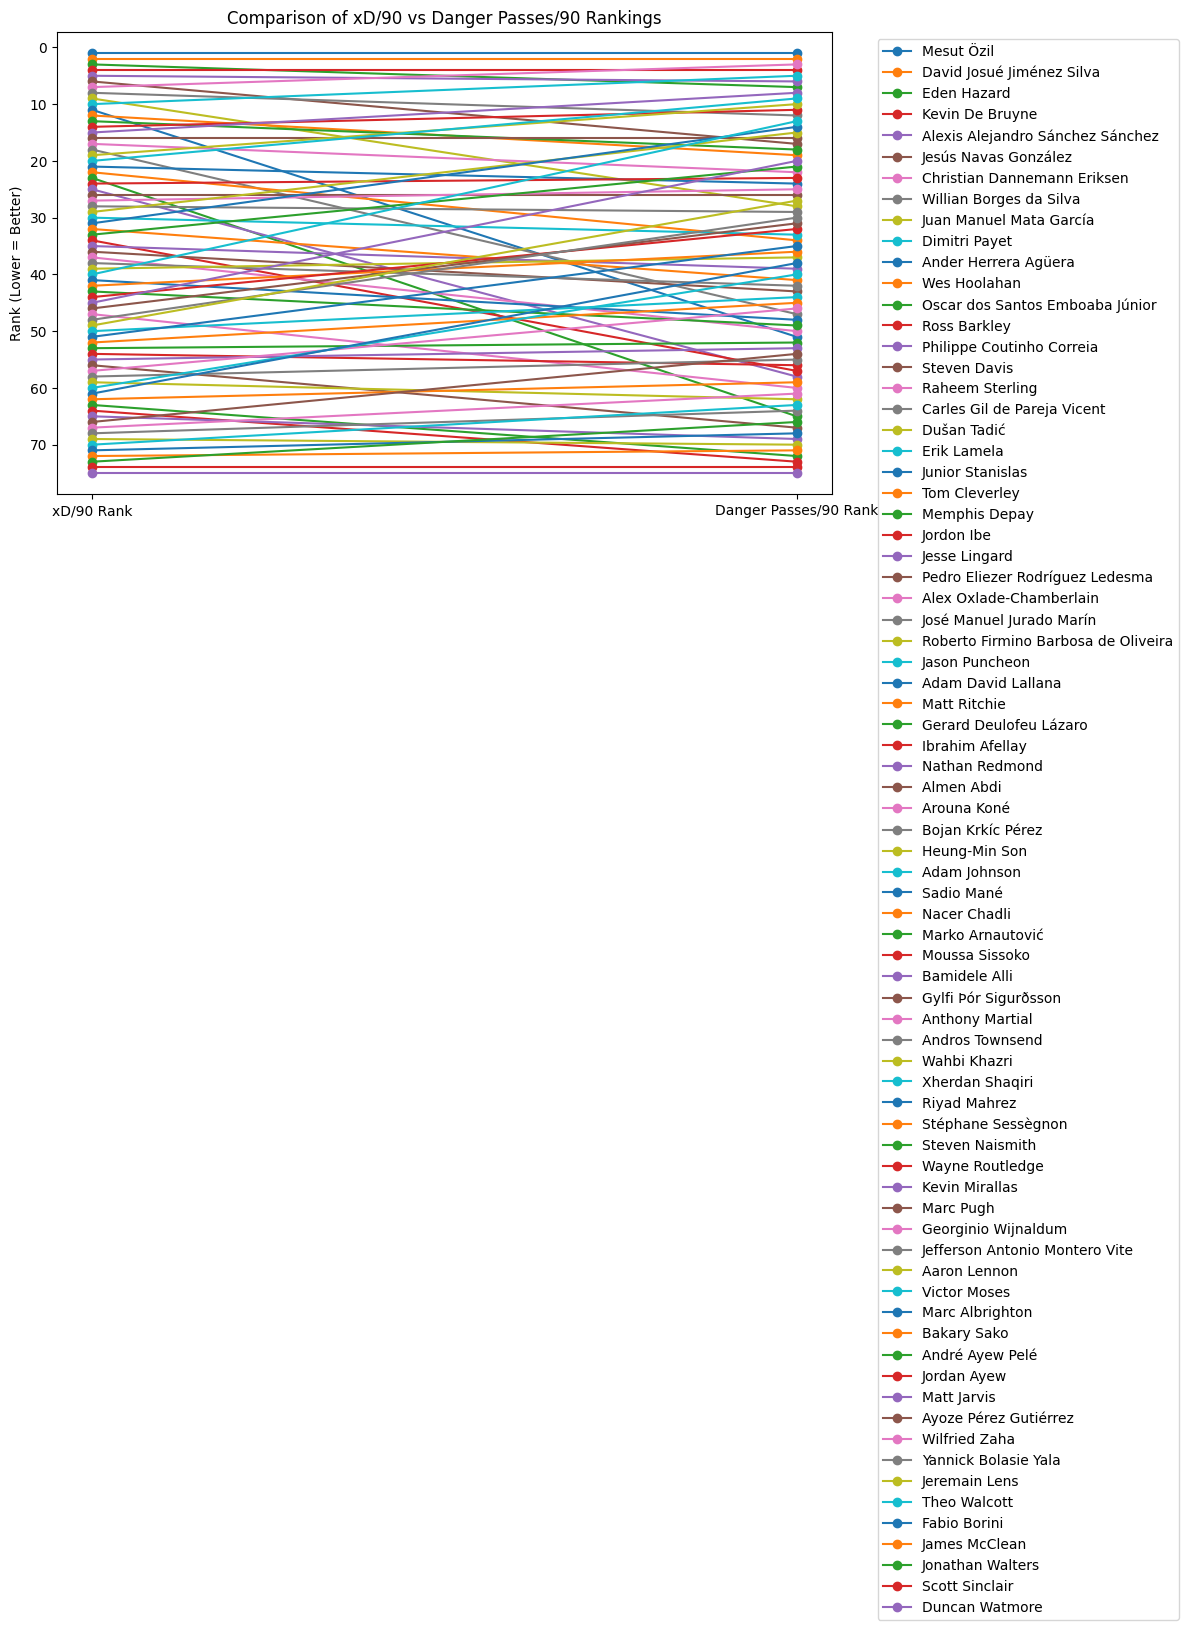

In [146]:
import matplotlib.pyplot as plt

# Choose one position group for clarity (e.g., Center Attacking Midfield)
position_df = filtered_df[filtered_df['position'] == 'Attacking Midfield/Winger']

# Sort by xD/90 rank
position_df = position_df.sort_values('xD/90_Rank')

plt.figure(figsize=(10, 6))

for i, row in position_df.iterrows():
    plt.plot([0, 1], [row['xD/90_Rank'], row['Danger_Passes/90_Rank']],
             marker='o', label=row['player'])

plt.xticks([0, 1], ['xD/90 Rank', 'Danger Passes/90 Rank'])
plt.ylabel('Rank (Lower = Better)')
plt.title('Comparison of xD/90 vs Danger Passes/90 Rankings')
plt.gca().invert_yaxis()  # So rank 1 is at the top
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


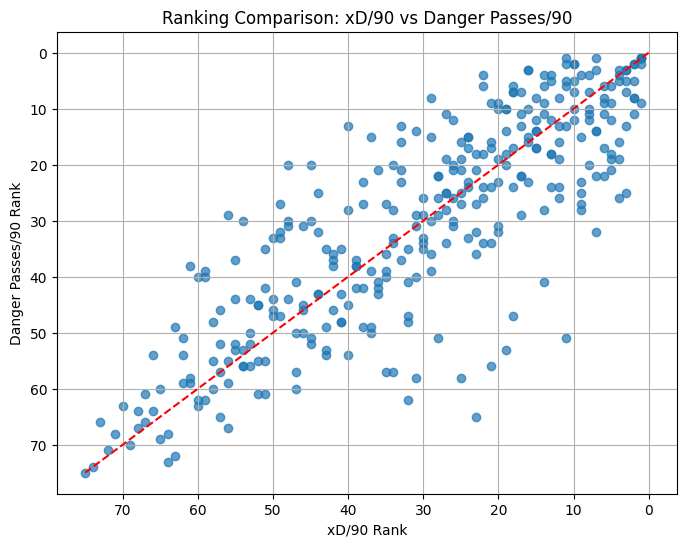

In [140]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['xD/90_Rank'], filtered_df['Danger_Passes/90_Rank'], alpha=0.7)

plt.xlabel('xD/90 Rank')
plt.ylabel('Danger Passes/90 Rank')
plt.title('Ranking Comparison: xD/90 vs Danger Passes/90')
plt.plot([0, filtered_df['xD/90_Rank'].max()],
         [0, filtered_df['xD/90_Rank'].max()], 'r--')  # diagonal line of agreement
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


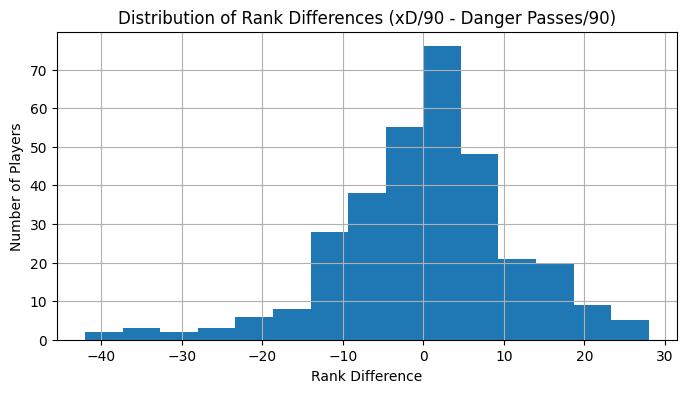

In [141]:
filtered_df['Rank_Difference'] = filtered_df['xD/90_Rank'] - filtered_df['Danger_Passes/90_Rank']

plt.figure(figsize=(8, 4))
filtered_df['Rank_Difference'].hist(bins=15)
plt.title('Distribution of Rank Differences (xD/90 - Danger Passes/90)')
plt.xlabel('Rank Difference')
plt.ylabel('Number of Players')
plt.grid(True)
plt.show()


In [145]:

filtered_df.nsmallest(5, 'Rank_Difference')[['player', 'position', 'xD/90_Rank', 'Danger_Passes/90_Rank']]


,player,position,xD/90_Rank,Danger_Passes/90_Rank
366,Memphis Depay,Left Wing,23,65
31,Ander Herrera Agüera,Center Attacking Midfield,11,51
379,Morgan Schneiderlin,Right Defensive Midfield,21,56
361,Matteo Darmian,Right Back,19,53
237,Jesse Lingard,Right Wing,25,58


In [173]:
filtered_df.nlargest(5, 'Rank_Difference')[['player', 'position', 'xD/90_Rank', 'Danger_Passes/90_Rank']]

,player,position,xD/90_Rank,Danger_Passes/90_Rank
234,Jeffrey Schlupp,Left Back,48,20
6,Adam Johnson,Right Wing,40,13
227,Jan Kirchhoff,Center Defensive Midfield,56,29
53,Bamidele Alli,Center Attacking Midfield,45,20
458,Sebastian Prödl,Right Center Back,54,30
